In [1]:
import pandas as pd

import numpy as np

pd.set_option('display.float_format','{:.2f}'.format)
df = pd.read_csv("house_price_regression_dataset.csv")

In [2]:
df.head()

,Square_Footage,Num_Bedrooms,Num_Bathrooms,Year_Built,Lot_Size,Garage_Size,Neighborhood_Quality,House_Price
0,1360,2,1,1981,0.60,0,5,262382.85
1,4272,3,3,2016,4.75,1,6,985260.85
2,3592,1,2,2016,3.63,0,9,777977.39
3,966,1,2,1977,2.73,1,8,229698.92
4,4926,2,1,1993,4.70,0,8,1041740.86


- Simple Linear Regression
- Multiple Linear Regression

Simple Linear Regression

- When we have sinlge input column and single output column.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression


X = df[['Square_Footage']]
y = df['House_Price']


X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [4]:
lr = LinearRegression()

model = lr.fit(X_train,y_train)



In [5]:
model.intercept_ # value of C

54229.05859587737

In [6]:
model.coef_ # value of m

array([200.55687687])

In [7]:
y_pred = model.predict(X_test)

In [8]:
from sklearn.metrics import r2_score

In [9]:
r2_score(y_test,y_pred)

0.9832220800154357

In [10]:
966 * 200.55687687 + 54229.05859587737

247967.00165229736

In [11]:
model.predict([[966]])

/opt/homebrew/lib/python3.11/site-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([247967.0016523])

In [12]:
import matplotlib.pyplot as plt

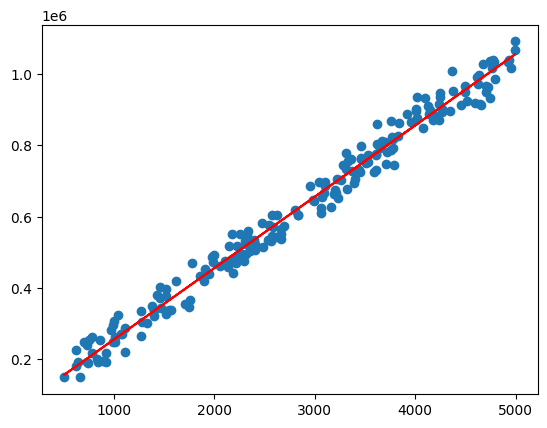

In [17]:
plt.scatter(X_test,y_test)
plt.plot(X_test,y_pred,c='red')

# Multiple Linear Regression

In [19]:
X = df.drop('House_Price',axis=1)
y = df['House_Price']

In [22]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)


In [26]:
X_train.columns

Index(['Square_Footage', 'Num_Bedrooms', 'Num_Bathrooms', 'Year_Built',
       'Lot_Size', 'Garage_Size', 'Neighborhood_Quality'],
      dtype='str')

In [23]:
lr = LinearRegression()

model = lr.fit(X_train,y_train)

In [24]:
model.intercept_

-2010567.4202702055

In [25]:
model.coef_

array([  199.5132451 , 10225.20442447,  8208.43477773,   993.53717106,
       14885.38441462,  5146.14838284,   115.06859524])

In [27]:
y_pred = model.predict(X_test)

In [31]:
sm_df = pd.DataFrame({"Square_Footage":[1360],	
                     "Num_Bedrooms":[2],	
                     "Num_Bathrooms":[1],	
                     "Year_Built":[1981],	
                     "Lot_Size":[0.60],	
                     "Garage_Size":[0],	
                     "Neighborhood_Quality":[5]})
pred = model.predict(sm_df)
print(pred)

[267133.14618708]


In [32]:
-2010567.4202702055 + 199.5132451*1360 + 10225.20442447*2 +  8208.43477773*1 +  993.53717106*1981 + 0.60*14885.38441462 +  5146.14838284*0 +   115.06859524*5

267133.1461872963

In [33]:
262382 - 267133

-4751

In [28]:
r2_score(y_test,y_pred)

0.9984263636823408

# Metric

In [38]:
from sklearn.metrics import mean_absolute_error

In [39]:
# MAE (Mean Absolute Error)

mean_absolute_error(y_test,y_pred)

8174.583600008774

In [41]:
np.sum(np.abs(y_test - y_pred))/200

8174.583600008774

In [44]:
#MSE (Mean squared Error)

from sklearn.metrics import mean_squared_error 

mse= mean_squared_error(y_test,y_pred)
print(mse)

101434798.5056691


In [43]:
np.mean(np.power(y_test-y_pred,2))

101434798.5056691

In [45]:
#RMSE (Root mean Squared error)

np.sqrt(mse)

10071.484424138733

In [47]:
r2_score(y_test,y_pred)

0.9984263636823408

In [49]:
1 - np.sum((y_test-y_pred)**2) / np.sum((y_test-np.mean(y_test))**2)

0.9984263636823408